In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve() / 'src'))

from dvrptw_bench.data.instance_filters import find_rc_instances, find_rc_solutions, find_c_instances, find_c_solutions
from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.heuristics.ortools_solver import ORToolsVRPTWSolver
from dvrptw_bench.heuristics.gls import GLSSolver
from dvrptw_bench.dynamic.simulator import DynamicSimulator
from dvrptw_bench.viz.route_plot import plot_routes
from dvrptw_bench.viz.timeline_plot import plot_timeline
from dvrptw_bench.viz.convergence_plot import plot_convergence
from dvrptw_bench.viz.inspector import inspect_dynamic, inspect_static 
from dvrptw_bench.rl.rl4co_runner import RL4COPolicy 
from dvrptw_bench.rl.rl4co_model_zoo import RLModel
import vrplib as vlib

import logging
import sys

gls_logger = logging.getLogger("dvrptw_bench.heuristics.gls")
gls_logger.handlers.clear()
out = Path('../outputs/notebook_heuristics')

handler = logging.StreamHandler(sys.stdout)  # send to notebook cell output
handler.setLevel(logging.DEBUG)
handler.setFormatter(logging.Formatter("%(asctime)s| %(levelname)s | %(message)s"))

gls_logger.addHandler(handler)
gls_logger.setLevel(logging.DEBUG)
gls_logger.propagate = False

In [2]:
# dataset_root = Path('../dataset')
# instances = find_rc_instances(dataset_root)
# best_solutions = find_rc_solutions(dataset_root)
# print(instances)
# print(best_solutions)

In [3]:
dataset_root = Path('../dataset')
instances = find_c_instances(dataset_root)
best_solutions = find_c_solutions(dataset_root)
bestSolutionsPath = find_c_solutions(dataset_root)
best_solutions = {}
for path in bestSolutionsPath:
    name = path.stem
    solution = vlib.read_solution(path)
    best_solutions[name] = solution
print(instances)
print(best_solutions)

[PosixPath('../dataset/solomon_c100/C101.txt'), PosixPath('../dataset/solomon_c100/C102.txt'), PosixPath('../dataset/solomon_c100/C103.txt'), PosixPath('../dataset/solomon_c100/C104.txt'), PosixPath('../dataset/solomon_c100/C105.txt'), PosixPath('../dataset/solomon_c100/C106.txt'), PosixPath('../dataset/solomon_c100/C107.txt'), PosixPath('../dataset/solomon_c100/C108.txt'), PosixPath('../dataset/solomon_c100/C109.txt')]
{'C101': {'routes': [[5, 3, 7, 8, 10, 11, 9, 6, 4, 2, 1, 75], [13, 17, 18, 19, 15, 16, 14, 12], [20, 24, 25, 27, 29, 30, 28, 26, 23, 22, 21], [32, 33, 31, 35, 37, 38, 39, 36, 34], [43, 42, 41, 40, 44, 46, 45, 48, 51, 50, 52, 49, 47], [57, 55, 54, 53, 56, 58, 60, 59], [67, 65, 63, 62, 74, 72, 61, 64, 68, 66, 69], [81, 78, 76, 71, 70, 73, 77, 79, 80], [90, 87, 86, 83, 82, 84, 85, 88, 89, 91], [98, 96, 95, 94, 92, 93, 97, 100, 99]], 'cost': 827.3}, 'C102': {'routes': [[5, 3, 7, 8, 10, 11, 9, 6, 4, 2, 1, 75], [13, 17, 18, 19, 15, 16, 14, 12], [20, 24, 25, 27, 29, 30, 28, 26

In [4]:
from dvrptw_bench.rl.rl4co_model_zoo import build_attention_model
time_budgets = [10,30,60,60*3, 60*5]

AM = build_attention_model()
policy = RL4COPolicy(AM)
policy.model.load('rl4co_model.pt')
solvers= [lambda: policy ]

/Users/giuseppe/Documents/personal/fyp-vrp/final_solution/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/final_solution/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/giuseppe/Documents/personal/fyp-vrp/final_solution/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensor

In [5]:
solutions = {}
for instance_path in instances:
    instance = parse_solomon(instance_path)
    # Cold Start
    for time_budget in time_budgets:
        for solver_cls in solvers:
            if(solver_cls == RL4COPolicy ):
                solution = solver_cls().infer(instance)
            else:
                solution = solver_cls().infer_instance(instance)
                # solution = solver_cls().solve(instance, time_limit_s=time_budget)
            solutions[(instance.instance_id, time_budget, solver_cls.__name__)] = solution
    print(f"Instance: {instance.instance_id}, Customers: {instance.n_customers}")

Instance: C101.txt, Customers: 100
Instance: C102.txt, Customers: 100
Instance: C103.txt, Customers: 100
Instance: C104.txt, Customers: 100
Instance: C105.txt, Customers: 100
Instance: C106.txt, Customers: 100
Instance: C107.txt, Customers: 100
Instance: C108.txt, Customers: 100
Instance: C109.txt, Customers: 100


   Instance Time Budget    Solver  Computed Cost  Best Known Cost      Gap %  Computed Routes  Best Known Routes
0      C101         10s  <lambda>      49.020351            827.3 -94.074658               23                 10
1      C101         30s  <lambda>      49.020351            827.3 -94.074658               23                 10
2      C101         60s  <lambda>      49.020351            827.3 -94.074658               23                 10
3      C101        180s  <lambda>      49.020351            827.3 -94.074658               23                 10
4      C101        300s  <lambda>      49.020351            827.3 -94.074658               23                 10
5      C102         10s  <lambda>      45.174381            827.3 -94.539541               19                 10
6      C102         30s  <lambda>      45.174381            827.3 -94.539541               19                 10
7      C102         60s  <lambda>      45.174381            827.3 -94.539541               19   

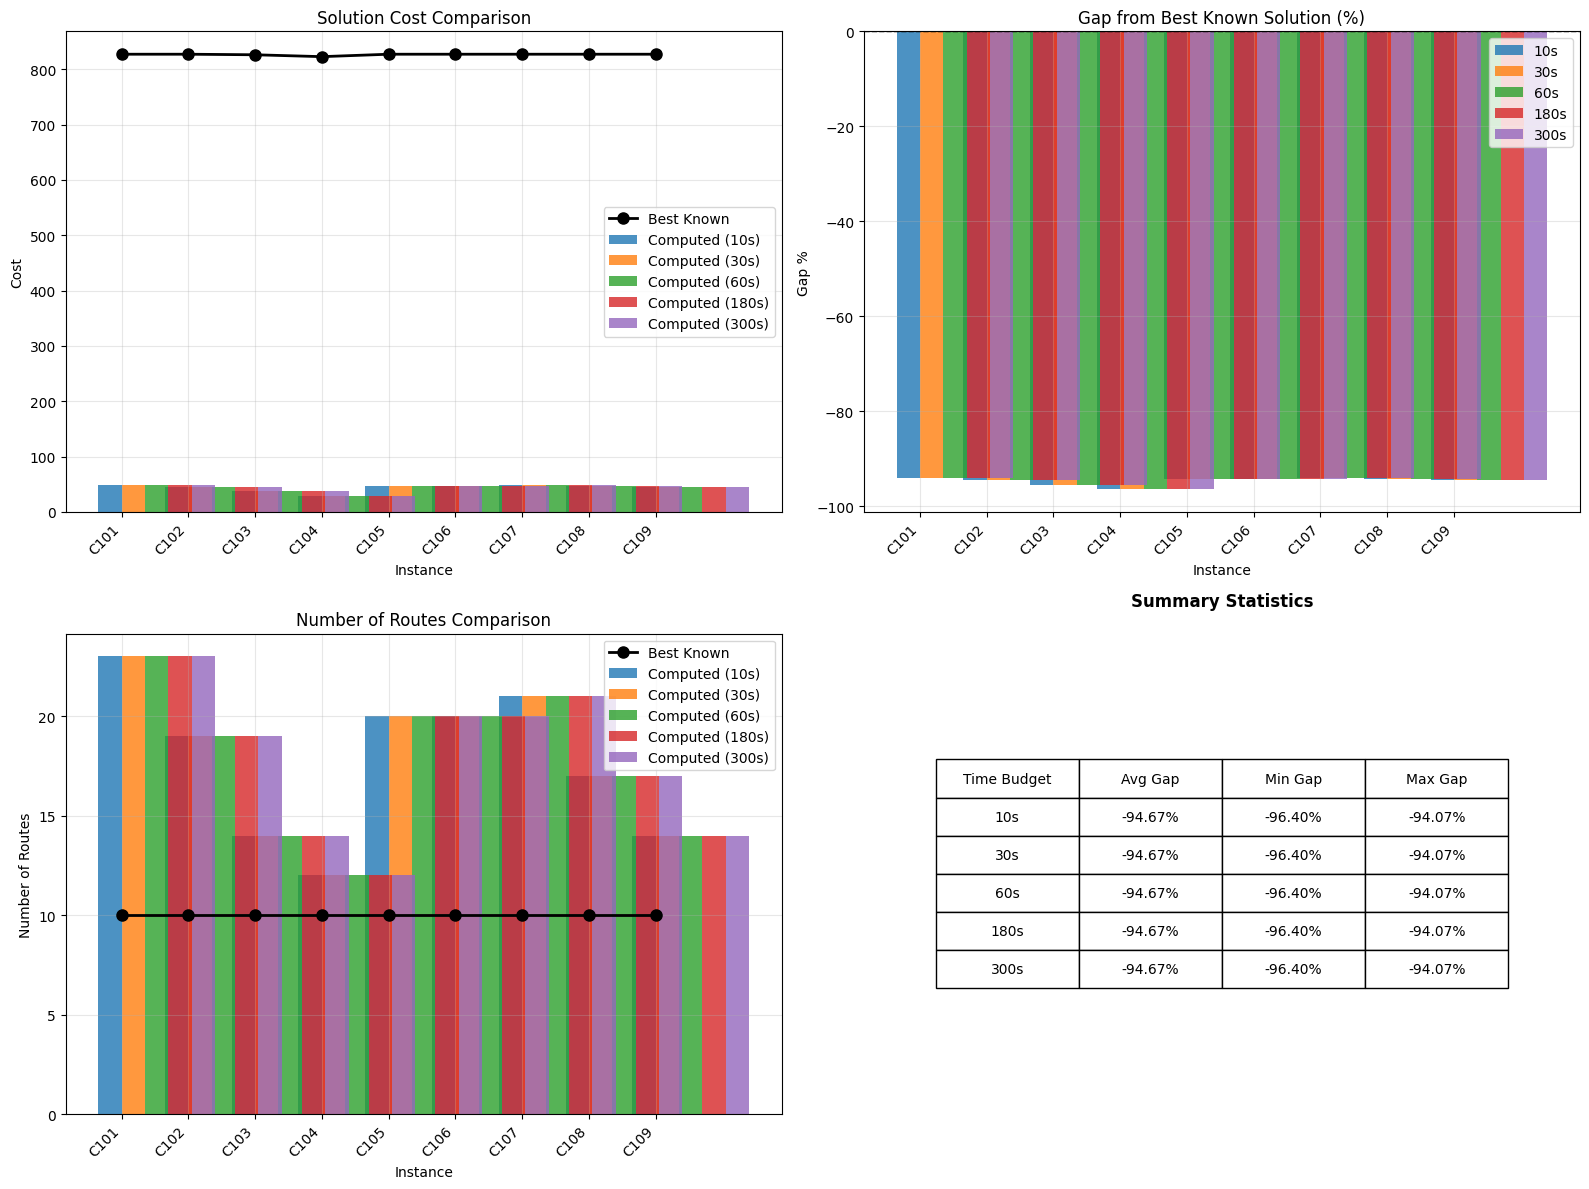

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prepare data for visualization
comparison_data = []

for key, solution in solutions.items():
    instance_file_name, time_budget, solver_name = key
    instance_name = instance_file_name.split('.')[0]
    best_solution = best_solutions.get(instance_name)
    
    if best_solution is not None:
        computed_cost = solution.total_distance
        best_cost = best_solution['cost']
        gap_percentage = ((computed_cost - best_cost) / best_cost) * 100
        
        comparison_data.append({
            'Instance': instance_name,
            'Time Budget': f'{time_budget}s',
            'Solver': solver_name,
            'Computed Cost': computed_cost,
            'Best Known Cost': best_cost,
            'Gap %': gap_percentage,
            'Computed Routes': len([x for x in solution.routes if len(x.node_ids) > 0]),
            'Best Known Routes': len(best_solution['routes'])
        })

df = pd.DataFrame(comparison_data)
print(df.to_string())

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Cost Comparison by Instance
ax1 = axes[0, 0]
instancesDf = df['Instance'].unique()
x = np.arange(len(instancesDf))
width = 0.35

for i, time_budget in enumerate(df['Time Budget'].unique()):
    df_budget = df[df['Time Budget'] == time_budget]
    computed = [df_budget[df_budget['Instance'] == inst]['Computed Cost'].values[0] 
                for inst in instancesDf]
    ax1.bar(x + i*width, computed, width, label=f'Computed ({time_budget})', alpha=0.8)

best = [df[df['Instance'] == inst]['Best Known Cost'].values[0] for inst in instancesDf]
ax1.plot(x + width/2, best, 'ko-', linewidth=2, markersize=8, label='Best Known', zorder=3)

ax1.set_xlabel('Instance')
ax1.set_ylabel('Cost')
ax1.set_title('Solution Cost Comparison')
ax1.set_xticks(x + width/2)
ax1.set_xticklabels(instancesDf, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Gap Percentage
ax2 = axes[0, 1]
for i, time_budget in enumerate(df['Time Budget'].unique()):
    df_budget = df[df['Time Budget'] == time_budget]
    gaps = [df_budget[df_budget['Instance'] == inst]['Gap %'].values[0] 
            for inst in instancesDf]
    ax2.bar(x + i*width, gaps, width, label=time_budget, alpha=0.8)

ax2.set_xlabel('Instance')
ax2.set_ylabel('Gap %')
ax2.set_title('Gap from Best Known Solution (%)')
ax2.set_xticks(x + width/2)
ax2.set_xticklabels(instancesDf, rotation=45, ha='right')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Number of Routes Comparison
ax3 = axes[1, 0]
for i, time_budget in enumerate(df['Time Budget'].unique()):
    df_budget = df[df['Time Budget'] == time_budget]
    computed_routes = [df_budget[df_budget['Instance'] == inst]['Computed Routes'].values[0] 
                       for inst in instancesDf]
    ax3.bar(x + i*width, computed_routes, width, label=f'Computed ({time_budget})', alpha=0.8)

best_routes = [df[df['Instance'] == inst]['Best Known Routes'].values[0] for inst in instancesDf]
ax3.plot(x + width/2, best_routes, 'ko-', linewidth=2, markersize=8, label='Best Known', zorder=3)

ax3.set_xlabel('Instance')
ax3.set_ylabel('Number of Routes')
ax3.set_title('Number of Routes Comparison')
ax3.set_xticks(x + width/2)
ax3.set_xticklabels(instancesDf, rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Summary Statistics
ax4 = axes[1, 1]
ax4.axis('off')

summary_stats = []
for time_budget in df['Time Budget'].unique():
    df_budget = df[df['Time Budget'] == time_budget]
    avg_gap = df_budget['Gap %'].mean()
    min_gap = df_budget['Gap %'].min()
    max_gap = df_budget['Gap %'].max()
    summary_stats.append([time_budget, f'{avg_gap:.2f}%', f'{min_gap:.2f}%', f'{max_gap:.2f}%'])

table = ax4.table(cellText=summary_stats, 
                 colLabels=['Time Budget', 'Avg Gap', 'Min Gap', 'Max Gap'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.2, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax4.set_title('Summary Statistics', pad=20, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

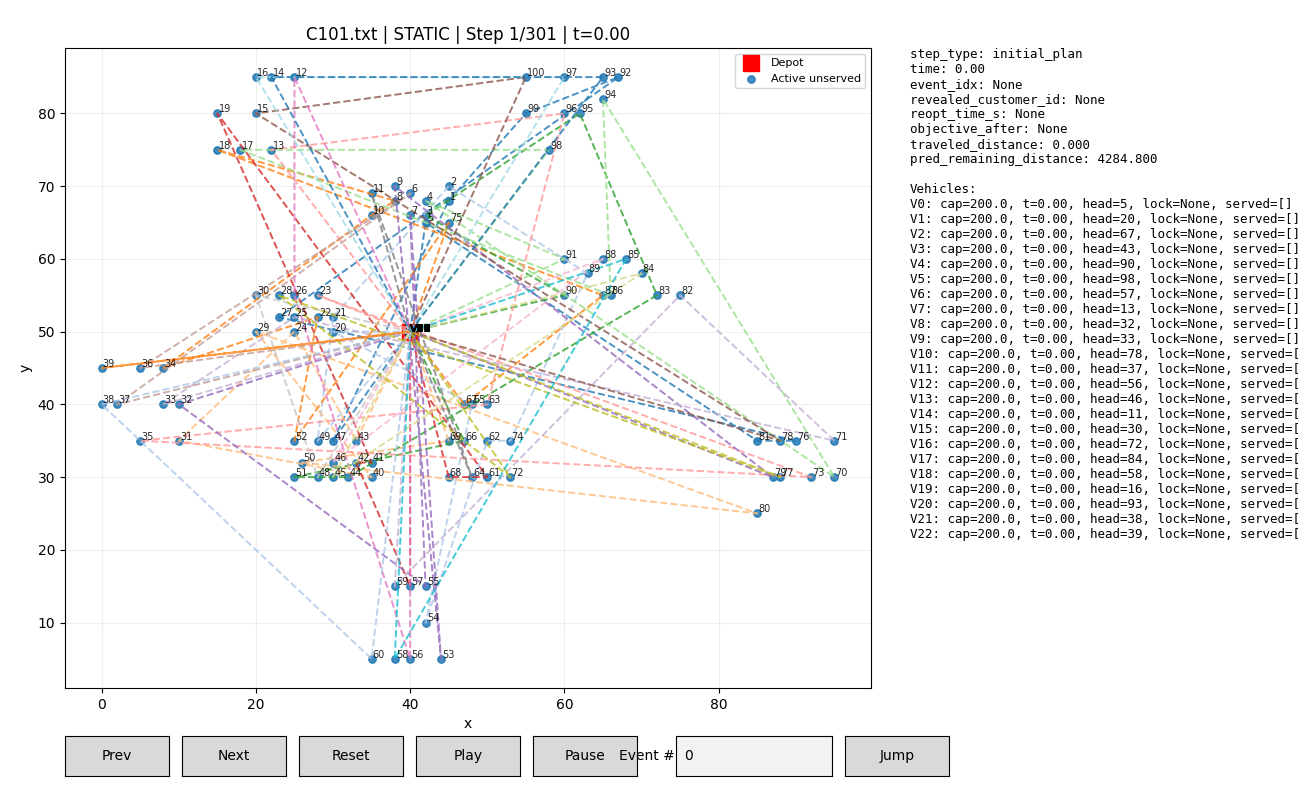

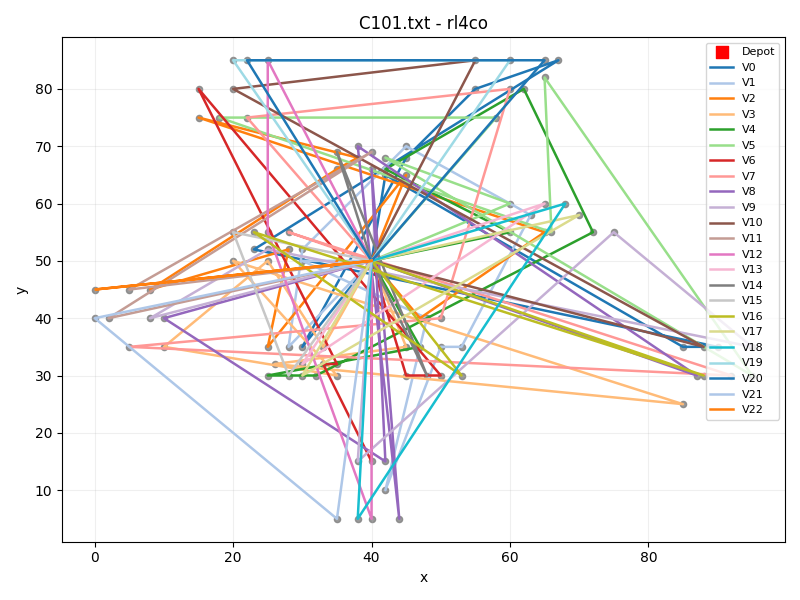

In [8]:

%matplotlib widget
from dvrptw_bench.viz.inspector import inspect_static
instance = parse_solomon(instances[0])
solution = solutions[(instance.instance_id, time_budgets[0], solvers[0].__name__)]
plot_routes(instance, solution, None)
inspect_static(instance, solution)

In [9]:
# Feasibility check:
from dvrptw_bench.dynamic.feasibility import verify_solution 

is_feasible = verify_solution(instance, solution)
is_feasible

FeasibilityReport(feasible=False, capacity_violation=0.0, time_violation=1771.4860411568036, unserved_customers=[])